# Hoja de Trabajo 2
## Vision Por Computadora

Integrantes:
- Francis Aguilar, 22243
- César López, 22535
- Jose Marchena, 22398

Repo:
https://github.com/MarchMol/hdt2_vision

## Task 1 - Análisis
Considere que usted está diseñando el sistema de visión para un robot de almacén que debe moverse entre estanterías para recoger productos. El robot tiene dos cámaras frontales:
1. Durante una prueba, el robot gira sobre su propio eje para escanear el entorno. El ingeniero junior a tu cargo sugiere usar Homografías para medir la distancia a los objetos mientras el robot gira. ¿Es este un enfoque correcto? Justifique su respuesta utilizando los conceptos de C1, C2 y Paralaje.

**R//**
Podemos definir dos camaras C1 y C2 para que representen la vision del robot. Ambas estan en la misma posicion pues el robot solo gira en su eje, y se diferencian unicamente en rotacion.
Dado que no hay traslacion no se introduce paralaje lo cual no es bueno en nuestro caso. Si no hay paralaje, significa que todos los puntos se moveran de igual manera sin importar su distancia al eje. Es decir, no tenemos informacion suficiente para inferir distancia a travez de una homografia sobre ambas perspectivas
Por tanto, este enfoque no es correcto, sin traslacion no hay paralaje y sin paralaje no podemos inferir distancias.

2. Si el robot comienza a avanzar (traslación) y detectas que la disparidad (d) de una caja aumenta repentinamente entre el frame t y el frame t+1, ¿qué puedes inferir sobre la distancia (Z) entre el robot y la caja? ¿Qué riesgo industrial implicaría un error en el cálculo de esta disparidad?

**R//**
Basandonos en la relacion disparidad-profundiad, nos indica que la distancia es inversamente proporcional a la disparidad. Tambien se puede interpretar intuitivamente diciendo que una la disparidad es alta entre frames significa que el objeto se movio rapidamente al trasladarnos en un frame. De cualquier manera, llegamos a la misma conclusion que el objeto es cercano y la distancia Z es pequeña con respecto al robot.

Un error en el calculo de esta disparidad podria causar problemas significativos. El mas riesgoso es que cause falsos negativos (no detecte disparidades altas) pues esto significa que no puede reconocer objetos cercanos. Esto podria llevar a choques con estanterias o incluso herir personal si se encuentra cercano a estos. falsos positivos podrian hacer tambien que el robot este mas lejos de lo que piense y no logre recoger cajas adecuadamente, lo que podria dañar productos (si no los recoge firmemente) o que simplemente no los pueda recoger lo que lo haria poco efectivo

## Task 2 – Ingeniería de Dimensiones
Como director de proyectos, debe asegurar que los modelos de IA quepan en la memoria de los dispositivos (Edge Computing). Por ello, tiene una imagen de entrada de alta resolución proveniente de una cámara industrial de 1280 x 720 píxeles. Se aplica una capa convolucional con los siguientes hiperparámetros
- Tamaño del Filtro (F): 5×5
- Padding (P): 2
- Stride (S): 2

----


Considerando esto, respodan:
1. Utilizando la fórmula vista en clase, calcule las dimensiones (Wout,Hout) del Mapa de Características resultante. Muestra el procedimiento.


La fórmula para una capa convolucional es:

$$
W_{out} = \left\lfloor \frac{W_{in} - F + 2P}{S} \right\rfloor + 1
$$

$$
H_{out} = \left\lfloor \frac{H_{in} - F + 2P}{S} \right\rfloor + 1
$$


Cálculo de $W_{out}$

$$
W_{out} = \left\lfloor \frac{1280 - 5 + 2(2)}{2} \right\rfloor + 1
$$

$$
W_{out} = \left\lfloor \frac{1280 - 5 + 4}{2} \right\rfloor + 1
$$

$$
W_{out} = \left\lfloor \frac{1279}{2} \right\rfloor + 1
$$

$$
W_{out} = \left\lfloor 639.5 \right\rfloor + 1
$$

$$
W_{out} = 639 + 1
$$

$$
W_{out} = \mathbf{640}
$$


Cálculo de $H_{out}$

$$
H_{out} = \left\lfloor \frac{720 - 5 + 2(2)}{2} \right\rfloor + 1
$$

$$
H_{out} = \left\lfloor \frac{720 - 5 + 4}{2} \right\rfloor + 1
$$

$$
H_{out} = \left\lfloor \frac{719}{2} \right\rfloor + 1
$$

$$
H_{out} = \left\lfloor 359.5 \right\rfloor + 1
$$

$$
H_{out} = 359 + 1
$$

$$
H_{out} = \mathbf{360}
$$

Dimensiones finales del mapa de características

$$
\mathbf{640 \times 360}
$$

El stride $S = 2$ reduce aproximadamente a la mitad la resolución espacial.

----

2. ¿Qué sucedería con el tamaño de la salida si decides cambiar el Padding a P=0 (Valid Padding)? ¿Cómo afectaría esto a la información de los bordes de la imagen (donde suelen estar las referencias de las paredes del almacén)?

Si utilizaramos un padding de 0, no se agregan ceros al rededor de la imagen y el filtro no cubre completamente los bordes. Esto hace que se pierda la información periférica y se reducen ligeramente las dimensiones espaciales.    
Si la información de las peredes y referencias suelen estar en los borden, el padding 0 puede disminuir la precisión en detección de los limites lo que hace que se pierda información importante aunque de igual manera se reduce levemente el consumo de memoria. 


## Task 3 – Criterio de Diseño
En la industria, el balance entre precisión y velocidad es clave. Analice los siguientes escenarios::
1. Usted está desarrollando un sistema de detección de grietas microscópicas en motores de avión. ¿Qué combinación de Stride y Pooling recomendaría para no perder detalles críticos en las primeras capas de la red? Justifique técnicamente..
2. Un cliente le pide que el sistema funcione en un procesador muy limitado (como una cámara inteligente con poca RAM). Explique cómo podrías utilizar el Stride y el Max Pooling estratégicamente para reducir la carga computacional sin eliminar las características más fuertes (activaciones) del Mapa de Características

## Task 4 – Implementación Práctica
Con esta parte se busca que puedan comprender la mecánica interna de la operación convolucional sin depender de librerías de alto nivel para la lógica central.Por ello realice lo siguiente:

-  Utilizando un lenguaje de programación (Python) y librerías básicas para manejo de matrices (como NumPy), implementa una función llamada manual_convolution(image, kernel, stride,padding).
-  Requisitos de la implementación:
    - La función debe recibir una matriz 2D (imagen en escala de grises) y un filtro (kernel) de tamaño N×N.
    - Debe aplicar primero el Zero-padding a la imagen de entrada según el valor de P.
    - Debe recorrer la imagen aplicando el producto punto (suma de productos elementales) respetando el Stride indicado.
    - La función debe retornar la matriz resultante (Feature Map).
-  Prueba de validación: Defina un filtro de detección de bordes verticales (filtro de Sobel o similar) y apliquelo a una imagen pequeña de prueba.
- Entrega: Suba su Jupyter Notebook con comentarios explicando cómo el desplazamiento del kernel afecta el tamaño de la matriz de salida.

Text(0.5, 1.0, 'Imagen reducida (256x256)')

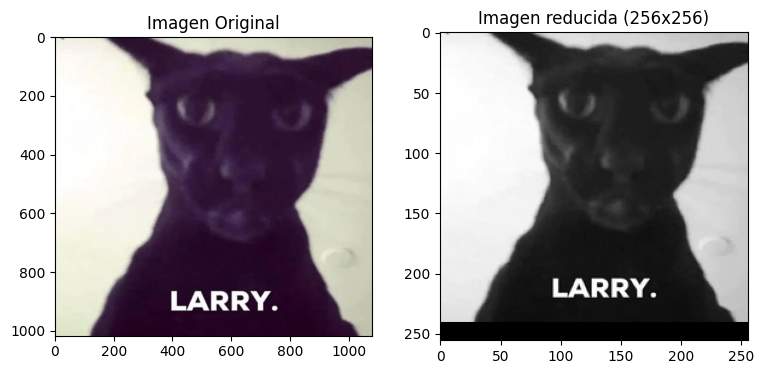

In [20]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load original
og_img = Image.open("./test.png")

# Resilze to 256 x 256
w, h = og_img.size
new_height = int((256 / w) * h)
img = og_img.resize((256, new_height), Image.Resampling.LANCZOS)
# Crop top-left 256x256 region
img = img.crop((0, 0, 256, 256))
img.save("resized.png")
img = np.array(img.convert('L'))

fig, ax = plt.subplots(1,2, figsize=(9,4))
ax[0].imshow(og_img)
ax[0].set_title("Imagen Original")

ax[1].imshow(img, cmap='gray')
ax[1].set_title("Imagen reducida (256x256)")

In [ ]:
# Convolucion Manual

def manual_convolucion(img, kernel, stride, padding):
    # Reflext kernel
    kernel = np.flip(kernel)
    # Tamaños
    r_h, r_w = img.shape
    k_h, k_w = kernel.shape
    # Applt padding
    img_array = np.pad(
        img,
        ((padding, padding), (padding, padding)),
        mode='constant'
    )
    
    # Tamaño de salida
    H_out = (r_h + 2*padding - k_h)//stride + 1
    W_out = (r_w + 2*padding - k_w)//stride + 1

    # actual convolution
    output = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            # Inicio con stride
            start_i = i * stride
            start_j = j * stride
            
            # slice
            window = img_array[
                start_i:start_i + k_h,
                start_j:start_j + k_w
            ]
            
            # np sum
            output[i][j] = np.sum(window * kernel) 
            
    return output

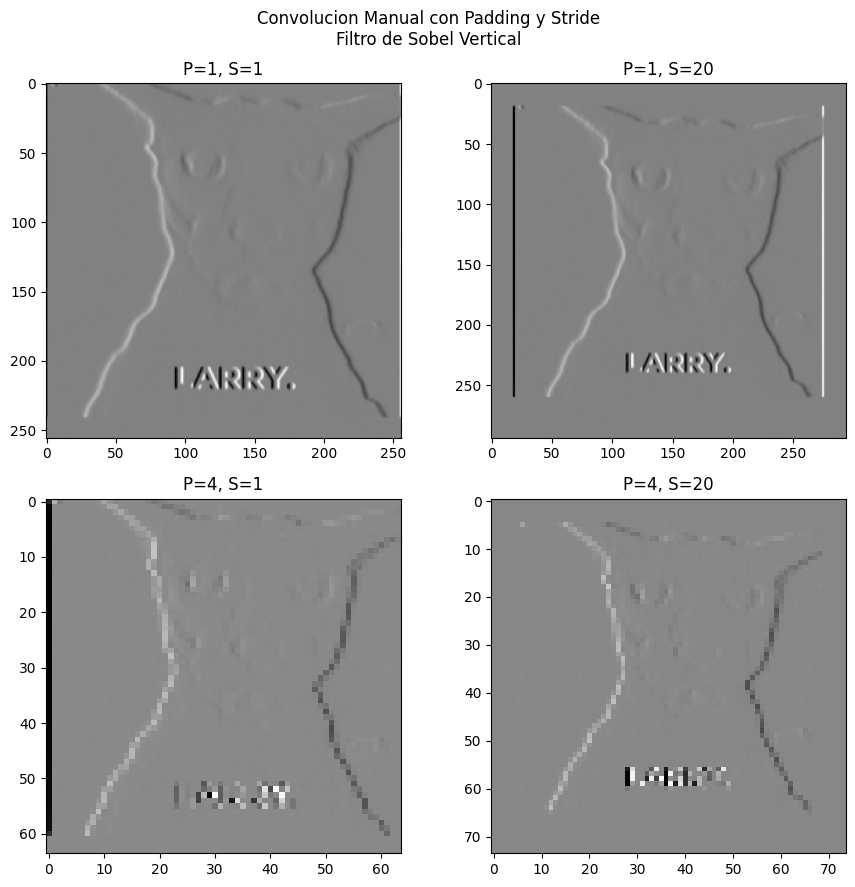

In [31]:
# Sobel vertical
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

out_11 = manual_convolucion(img, kernel, 1, 1)
out_12 = manual_convolucion(img, kernel, 1, 20)
out_21 = manual_convolucion(img, kernel, 4, 1)
out_22 = manual_convolucion(img, kernel, 4, 20)

fig, ax = plt.subplots(2,2,figsize=(9,9))
fig.suptitle("Convolucion Manual con Padding y Stride\nFiltro de Sobel Vertical")

ax[0][0].set_title("P=1, S=1")
ax[0][0].imshow(out_11, cmap="gray")

ax[0][1].set_title("P=1, S=20")
ax[0][1].imshow(out_12, cmap="gray")

ax[1][0].set_title("P=4, S=1")
ax[1][0].imshow(out_21, cmap="gray")

ax[1][1].set_title("P=4, S=20")
ax[1][1].imshow(out_22, cmap="gray")
fig.tight_layout()

Entrega: Suba su Jupyter Notebook con comentarios explicando cómo el desplazamiento del kernel
afecta el tamaño de la matriz de salida.

**R//**
El stride del kernel afecta el tamaño de salida de manera inversamente proporcional. Es decir un stride de 2, hace que el resultado sea 1/2 del tamaño original, un stride de 3 hace que sea 1/3 el tamaño, etc.
Esto es porque entre mas grande es el stride se puede ver como que nos vamos saltando pixeles y la convolucion ya no aplica 1 a 1.
